<a href="https://colab.research.google.com/github/fabricioFolmer/Graphic_Computing/blob/main/AnaliseNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carregando dados de: News_Final.csv
Arquivo carregado com sucesso usando UTF-8.
Total de 93239 linhas e 11 colunas carregadas.

--- Limpando e Preparando os Dados ---
Convertendo 'PublishDate' para datetime...
Tratando strings vazias em 'Topic' e 'Source'...
Strings vazias em 'Topic' substituídas por 'Unknown': 0
Strings vazias em 'Source' substituídas por 'Unknown': 0
Tratando valores '-1' nas colunas de redes sociais como NaN...
Valores -1 em 'Facebook' substituídos por NaN. Total de NaN: 11602
Valores -1 em 'GooglePlus' substituídos por NaN. Total de NaN: 5744
Valores -1 em 'LinkedIn' substituídos por NaN. Total de NaN: 5745

--- Informações Básicas do DataFrame ---
Primeiras 5 linhas:
    IDLink                                              Title  \
0  99248.0   Obama Lays Wreath at Arlington National Cemetery   
1  10423.0        A Look at the Health of the Chinese Economy   
2  18828.0   Nouriel Roubini: Global Economy Not Back to 2008   
3  27788.0                          Finlan

<ipython-input-2-a79de1d990a7>:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Topic'].replace('', 'Unknown', inplace=True)
<ipython-input-2-a79de1d990a7>:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

              IDLink                    PublishDate  SentimentTitle  \
count   93239.000000                          93239    93239.000000   
mean    51560.653257  2016-03-05 17:29:57.399972096       -0.005411   
min         1.000000            2002-04-02 00:00:00       -0.950694   
1%        957.380000     2015-11-09 21:40:10.380000       -0.375000   
25%     24301.500000            2016-01-07 19:39:28       -0.079057   
50%     52275.000000            2016-03-04 20:56:06        0.000000   
75%     76585.500000            2016-05-04 08:15:06        0.064255   
99%    103841.620000     2016-07-05 02:50:16.940000        0.355756   
max    104802.000000            2016-07-07 16:16:11        0.962354   
std     30391.078704                            NaN        0.136431   

       SentimentHeadline      Facebook    GooglePlus      LinkedIn  
count       93239.000000  81637.000000  87495.000000  87494.000000  
mean           -0.027493    129.362752      4.209281     17.700185  
min        

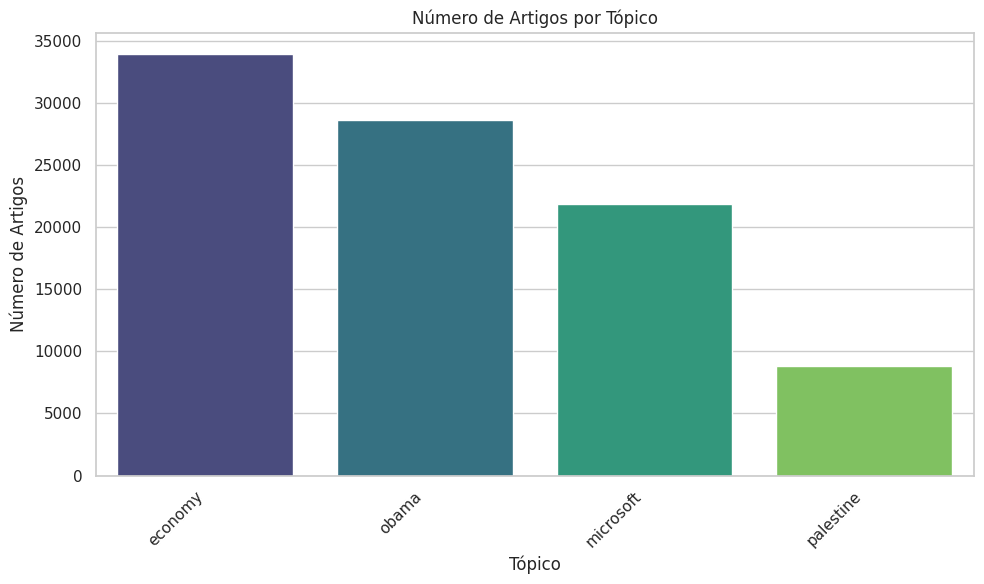


--- Análise de Fontes ---
Top 20 Fontes por Contagem de Artigos:
Source
Bloomberg                     1732
Reuters                       1321
ABC News                      1098
New York Times                 992
The Guardian                   933
Business Insider               884
Economic Times                 787
Forbes                         781
Washington Post                774
CNN                            742
Wall Street Journal            730
WinBeta                        707
CNBC                           682
Huffington Post                676
Breitbart News                 605
Reuters via Yahoo! Finance     551
The Hill                       548
Financial Times                544
USA TODAY                      530
ZDNet                          526
Name: count, dtype: int64


<ipython-input-2-a79de1d990a7>:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)


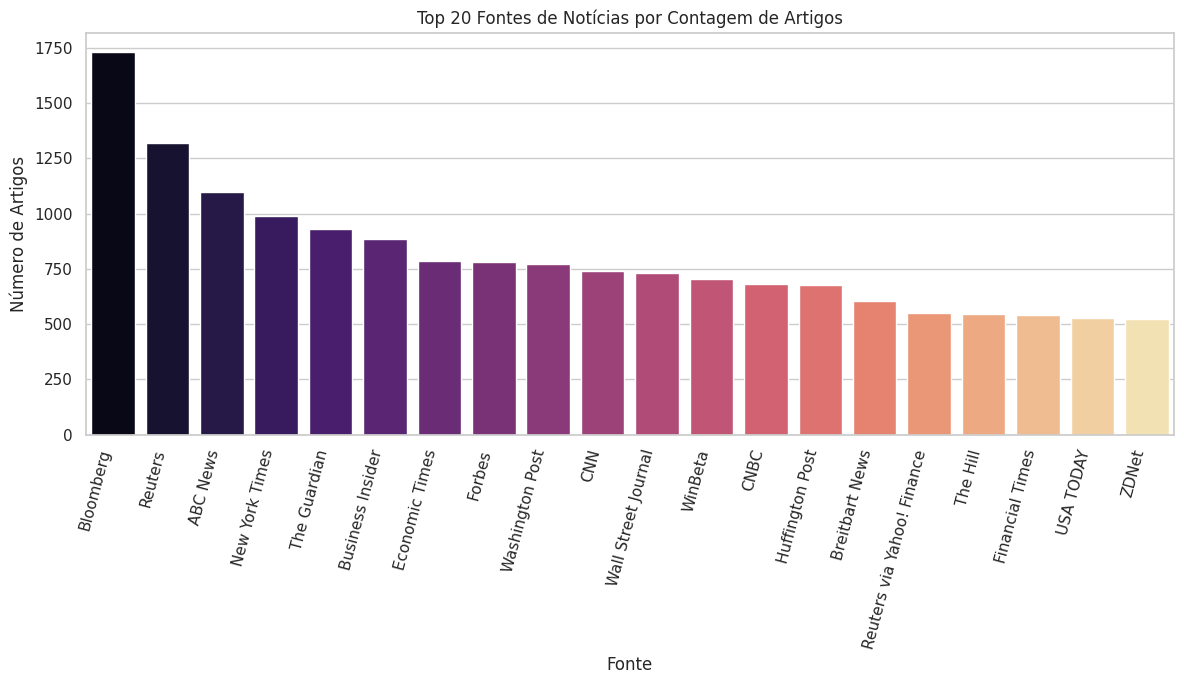


--- Análise de Sentimento ---


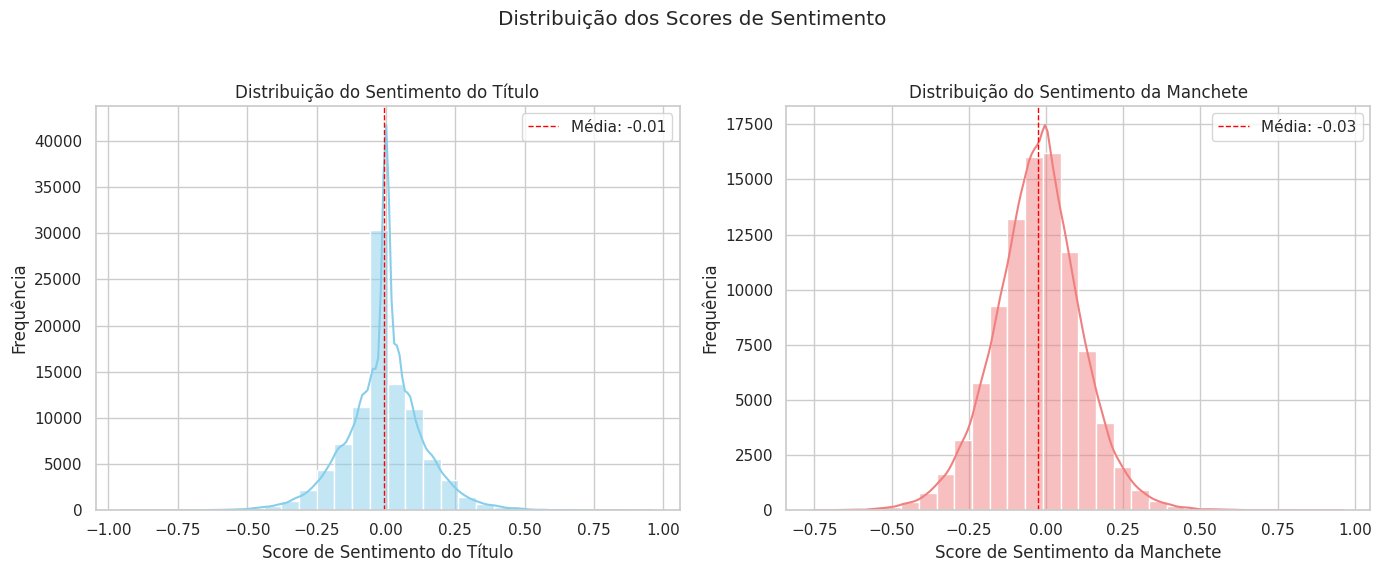


Sentimento Médio por Tópico:
           SentimentTitle  SentimentHeadline
Topic                                       
microsoft        0.002359          -0.014744
obama           -0.000965          -0.017743
economy         -0.010342          -0.039499
palestine       -0.020085          -0.044485


<ipython-input-2-a79de1d990a7>:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Topic', y='SentimentHeadline', palette='coolwarm', order=order_topics)


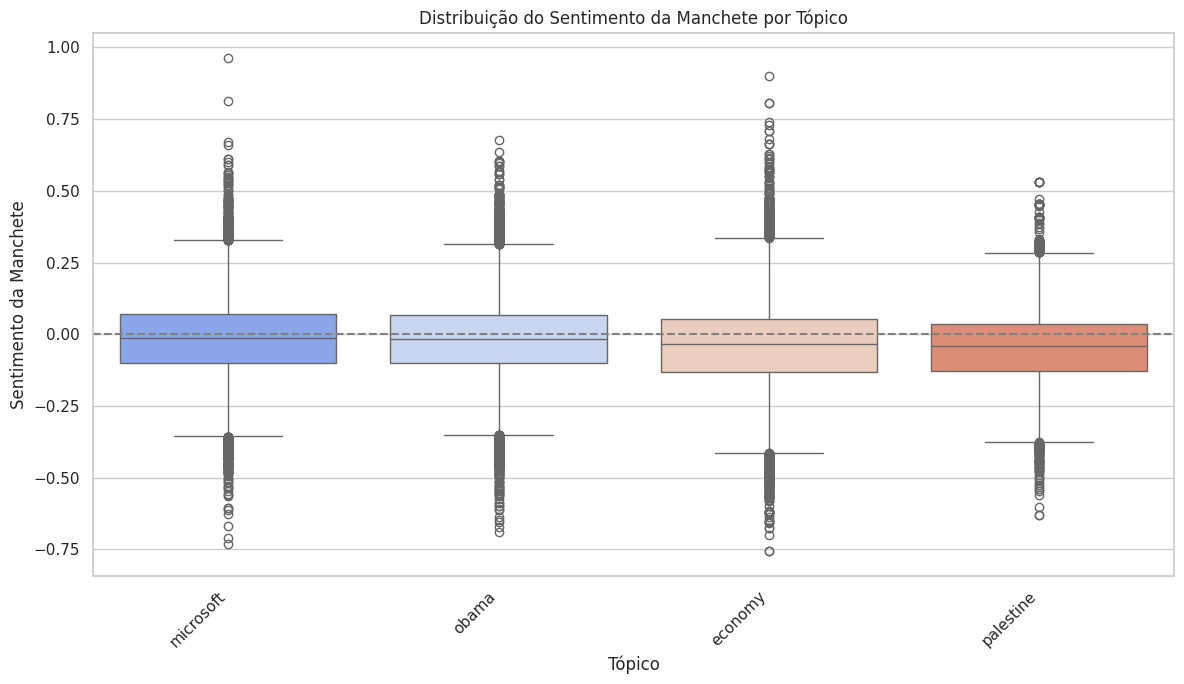


--- Análise Temporal ---


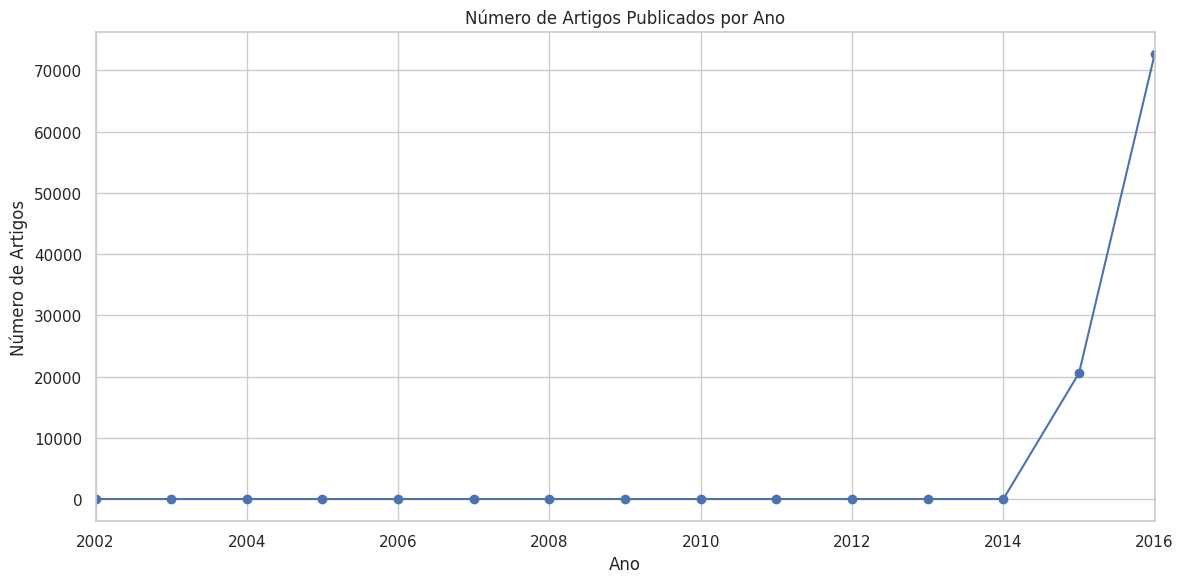

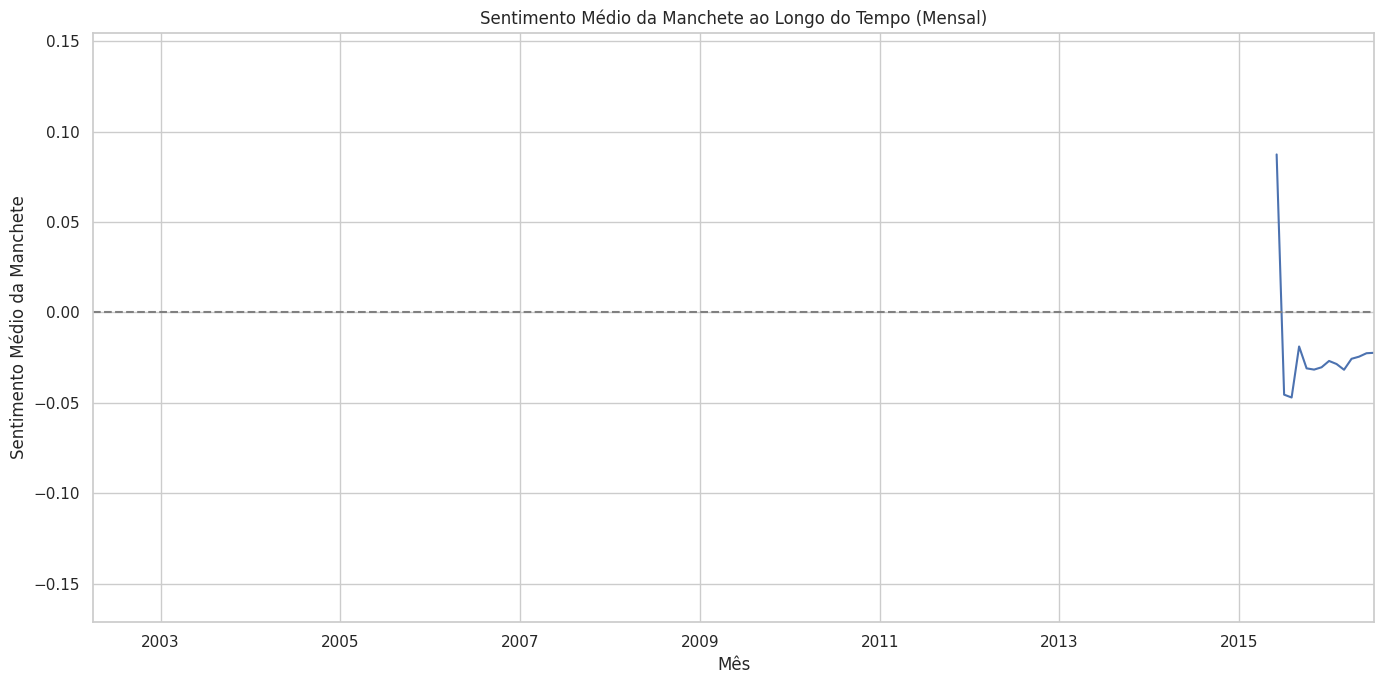


--- Análise de Redes Sociais ---
Matriz de Correlação (Sentimento vs. Engajamento Social):
                   SentimentTitle  SentimentHeadline  Facebook  GooglePlus  \
SentimentTitle           1.000000           0.183555 -0.003908   -0.010865   
SentimentHeadline        0.183555           1.000000  0.000590    0.001595   
Facebook                -0.003908           0.000590  1.000000    0.518519   
GooglePlus              -0.010865           0.001595  0.518519    1.000000   
LinkedIn                 0.003423           0.006026  0.137959    0.263477   

                   LinkedIn  
SentimentTitle     0.003423  
SentimentHeadline  0.006026  
Facebook           0.137959  
GooglePlus         0.263477  
LinkedIn           1.000000  


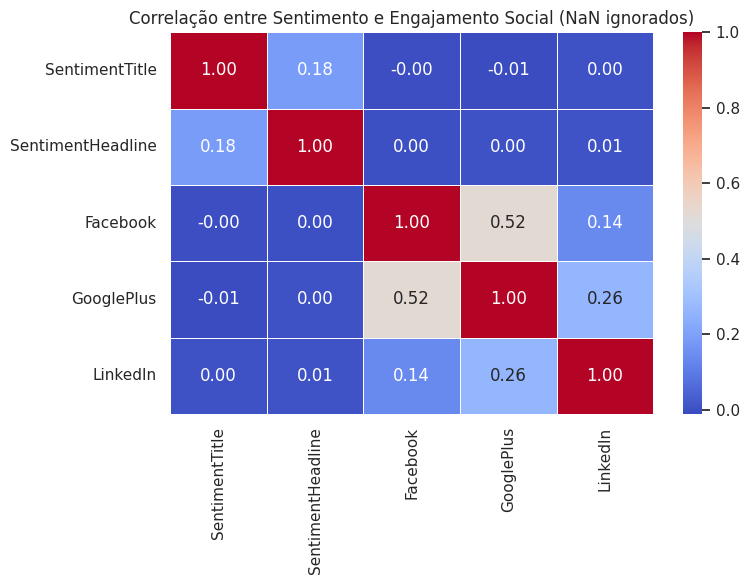


Número de artigos com pelo menos uma métrica social válida (não era -1): 87495 (93.84%)

--- Análise Concluída ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Para usar np.nan (nulos)

# --- Configurações ---
# Para melhor visualização dos plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7) # Define um tamanho padrão para os plots

# --- 1. Carregar os Dados ---
file_path = 'News_Final.csv'
print(f"Carregando dados de: {file_path}")

try:
    # Tenta carregar com a codificação padrão (UTF-8)
    df = pd.read_csv(file_path)
    print("Arquivo carregado com sucesso usando UTF-8.")
except UnicodeDecodeError:
    print("Falha ao carregar com UTF-8. Tentando com 'latin1'...")
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print("Arquivo carregado com sucesso usando 'latin1'.")
    except Exception as e:
        print(f"Erro ao carregar o arquivo CSV com diferentes codificações: {e}")
        exit() # Encerra se não conseguir carregar
except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado.")
    exit()
except Exception as e:
    print(f"Ocorreu um erro inesperado ao carregar o arquivo: {e}")
    exit()

print(f"Total de {len(df)} linhas e {len(df.columns)} colunas carregadas.")

# --- 2. Limpeza e Preparação dos Dados ---
print("\n--- Limpando e Preparando os Dados ---")

# Converter 'PublishDate' para datetime
print("Convertendo 'PublishDate' para datetime...")
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')
invalid_dates = df['PublishDate'].isnull().sum()
if invalid_dates > 0:
    print(f"AVISO: {invalid_dates} linhas tinham datas inválidas e foram definidas como NaT.")
    # Decisão: Remover linhas com datas inválidas para análise temporal
    df.dropna(subset=['PublishDate'], inplace=True)
    print(f"Linhas com datas inválidas removidas. Novo total de linhas: {len(df)}")

# Tratar strings vazias em 'Topic' e 'Source'
print("Tratando strings vazias em 'Topic' e 'Source'...")
df['Topic'].replace('', 'Unknown', inplace=True)
df['Source'].replace('', 'Unknown', inplace=True)
print(f"Strings vazias em 'Topic' substituídas por 'Unknown': {(df['Topic'] == 'Unknown').sum()}")
print(f"Strings vazias em 'Source' substituídas por 'Unknown': {(df['Source'] == 'Unknown').sum()}")

# Tratar valores -1 nas colunas de redes sociais como NaN (Not a Number/Missing)
social_cols = ['Facebook', 'GooglePlus', 'LinkedIn']
print("Tratando valores '-1' nas colunas de redes sociais como NaN...")
for col in social_cols:
    # Certifica-se que a coluna é numérica antes de substituir
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(-1, np.nan)
    print(f"Valores -1 em '{col}' substituídos por NaN. Total de NaN: {df[col].isnull().sum()}")

# Garantir tipos numéricos para sentimentos
df['SentimentTitle'] = pd.to_numeric(df['SentimentTitle'], errors='coerce')
df['SentimentHeadline'] = pd.to_numeric(df['SentimentHeadline'], errors='coerce')

# --- 3. Informações Básicas ---
print("\n--- Informações Básicas do DataFrame ---")
print("Primeiras 5 linhas:")
print(df.head())

print("\nInformações Gerais (Tipos de Dados, Valores Não-Nulos):")
df.info()

print("\nEstatísticas Descritivas (Colunas Numéricas):")
# Incluindo percentis para melhor entendimento da distribuição
print(df.describe(percentiles=[.01, .25, .5, .75, .99]))

print("\nContagem de Valores Ausentes por Coluna (após limpeza inicial):")
print(df.isnull().sum())

# --- 4. Análise de Tópicos ---
print("\n--- Análise de Tópicos ---")
topic_counts = df['Topic'].value_counts()
print("Contagem de Artigos por Tópico:")
print(topic_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis', order=topic_counts.index)
plt.title('Número de Artigos por Tópico')
plt.xlabel('Tópico')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 5. Análise de Fontes ---
print("\n--- Análise de Fontes ---")
source_counts = df['Source'].value_counts()
top_n_sources = 20
print(f"Top {top_n_sources} Fontes por Contagem de Artigos:")
print(source_counts.head(top_n_sources))

plt.figure(figsize=(12, 7))
sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)
plt.title(f'Top {top_n_sources} Fontes de Notícias por Contagem de Artigos')
plt.xlabel('Fonte')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

# --- 6. Análise de Sentimento ---
print("\n--- Análise de Sentimento ---")

# Distribuição dos Scores de Sentimento
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['SentimentTitle'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Sentimento do Título')
plt.xlabel('Score de Sentimento do Título')
plt.ylabel('Frequência')
plt.axvline(df['SentimentTitle'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Média: {df["SentimentTitle"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df['SentimentHeadline'].dropna(), bins=30, kde=True, color='lightcoral')
plt.title('Distribuição do Sentimento da Manchete')
plt.xlabel('Score de Sentimento da Manchete')
plt.ylabel('Frequência')
plt.axvline(df['SentimentHeadline'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Média: {df["SentimentHeadline"].mean():.2f}')
plt.legend()

plt.suptitle('Distribuição dos Scores de Sentimento')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para o título geral
plt.show()

# Sentimento Médio por Tópico
print("\nSentimento Médio por Tópico:")
avg_sentiment_topic = df.groupby('Topic')[['SentimentTitle', 'SentimentHeadline']].mean().sort_values('SentimentHeadline', ascending=False)
print(avg_sentiment_topic)

# Boxplot de Sentimento da Manchete por Tópico
plt.figure(figsize=(12, 7))
# Ordena os tópicos pela mediana do sentimento para melhor visualização
order_topics = df.groupby('Topic')['SentimentHeadline'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Topic', y='SentimentHeadline', palette='coolwarm', order=order_topics)
plt.title('Distribuição do Sentimento da Manchete por Tópico')
plt.xlabel('Tópico')
plt.ylabel('Sentimento da Manchete')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linestyle='--') # Linha neutra
plt.tight_layout()
plt.show()

# --- 7. Análise Temporal ---
print("\n--- Análise Temporal ---")
# Define 'PublishDate' como índice para facilitar a reamostragem
df_time = df.set_index('PublishDate')

# Número de artigos por ano
plt.figure(figsize=(12, 6))
df_time.resample('YE').size().plot(kind='line', marker='o') # YE = Year End
plt.title('Número de Artigos Publicados por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Artigos')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sentimento médio da manchete ao longo do tempo (mensal)
plt.figure(figsize=(14, 7))
df_time.resample('ME')['SentimentHeadline'].mean().plot(kind='line') # ME = Month End
plt.title('Sentimento Médio da Manchete ao Longo do Tempo (Mensal)')
plt.xlabel('Mês')
plt.ylabel('Sentimento Médio da Manchete')
plt.axhline(0, color='grey', linestyle='--') # Linha neutra
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 8. Análise de Redes Sociais (Correlação com Sentimento) ---
print("\n--- Análise de Redes Sociais ---")
# Calcula a correlação entre scores de sentimento e contagens de redes sociais
# Nota: .corr() ignora NaN por padrão
correlation_matrix = df[['SentimentTitle', 'SentimentHeadline'] + social_cols].corr()

print("Matriz de Correlação (Sentimento vs. Engajamento Social):")
print(correlation_matrix)

# Visualiza a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Sentimento e Engajamento Social (NaN ignorados)')
plt.tight_layout()
plt.show()

# Contagem de artigos com pelo menos um dado de rede social válido (> -1)
tracked_articles_count = df[social_cols].dropna(how='all').shape[0]
print(f"\nNúmero de artigos com pelo menos uma métrica social válida (não era -1): {tracked_articles_count} ({tracked_articles_count / len(df) * 100:.2f}%)")

print("\n--- Análise Concluída ---")


=== 1. EXPLORAÇÃO INICIAL DOS DADOS ===

1.1 Carregando dataset de: News_Final.csv
Dataset carregado com sucesso (UTF-8).

1.2 Descrição Geral do Dataset (Inicial)
Número de Registros (Linhas): 93239
Número de Colunas: 11

Nomes das Colunas:
['IDLink', 'Title', 'Headline', 'Source', 'Topic', 'PublishDate', 'SentimentTitle', 'SentimentHeadline', 'Facebook', 'GooglePlus', 'LinkedIn']

Tipos de Dados por Coluna:
IDLink               float64
Title                 object
Headline              object
Source                object
Topic                 object
PublishDate           object
SentimentTitle       float64
SentimentHeadline    float64
Facebook               int64
GooglePlus             int64
LinkedIn               int64
dtype: object

Primeiras 5 Linhas:
    IDLink                                              Title                                           Headline                                    Source    Topic          PublishDate  SentimentTitle  SentimentHeadline  Facebook  G

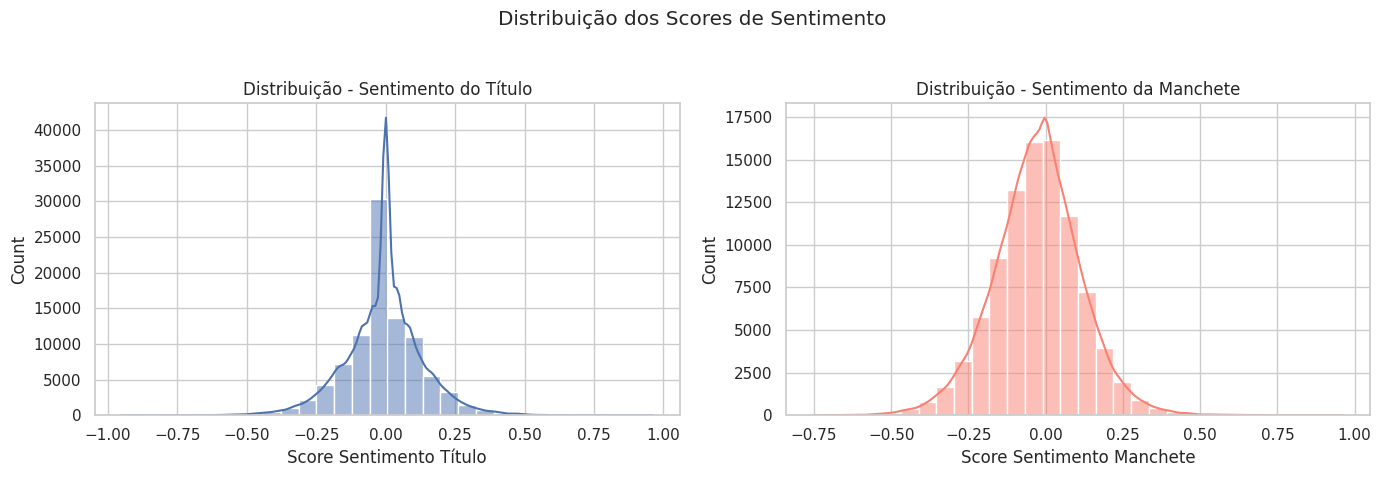

<ipython-input-2-cb9e851513e7>:230: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  topic_plot = sns.countplot(y=df['Topic'], order=df['Topic'].value_counts().index, palette='viridis')
<ipython-input-2-cb9e851513e7>:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  source_plot = sns.countplot(y=df[df['Source'].isin(top_sources.index)]['Source'], order=top_sources.index, palette='magma')


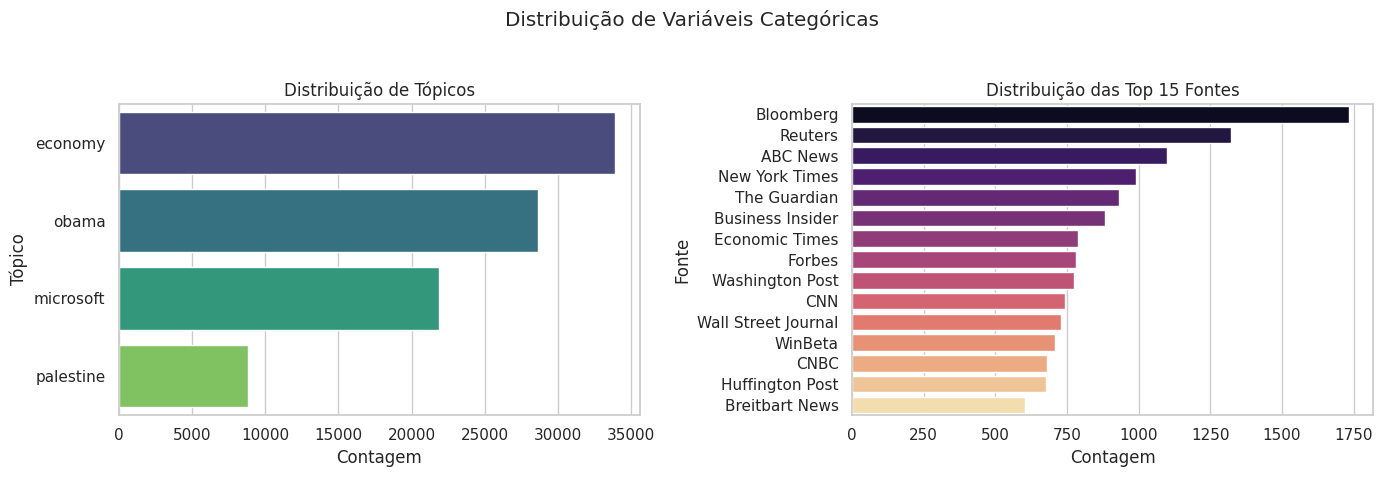


2.3 Análise de Cardinalidade e Variabilidade:
Contagem de Valores Únicos por Coluna:
IDLink               93235
Headline             86694
PublishDate          82644
Title                81259
SentimentHeadline    41257
SentimentTitle       14188
Source                5756
Facebook              2527
LinkedIn               844
GooglePlus             291
Topic                    4
dtype: int64

Colunas com potencial Alta Cardinalidade (Ex: >50% únicas): ['IDLink', 'Headline', 'PublishDate', 'Title']
Colunas com potencial Baixa Cardinalidade (Ex: <=5 únicas): ['Topic']

Variabilidade (Desvio Padrão para numéricas - ver describe() acima)
Distribuição de Frequência para Tópicos (Exemplo de variabilidade categórica):
Topic
economy      36.388207
obama        30.684585
microsoft    23.442980
palestine     9.484229
Name: proportion, dtype: float64

2.4 Identificação de Outliers e Erros Potenciais:


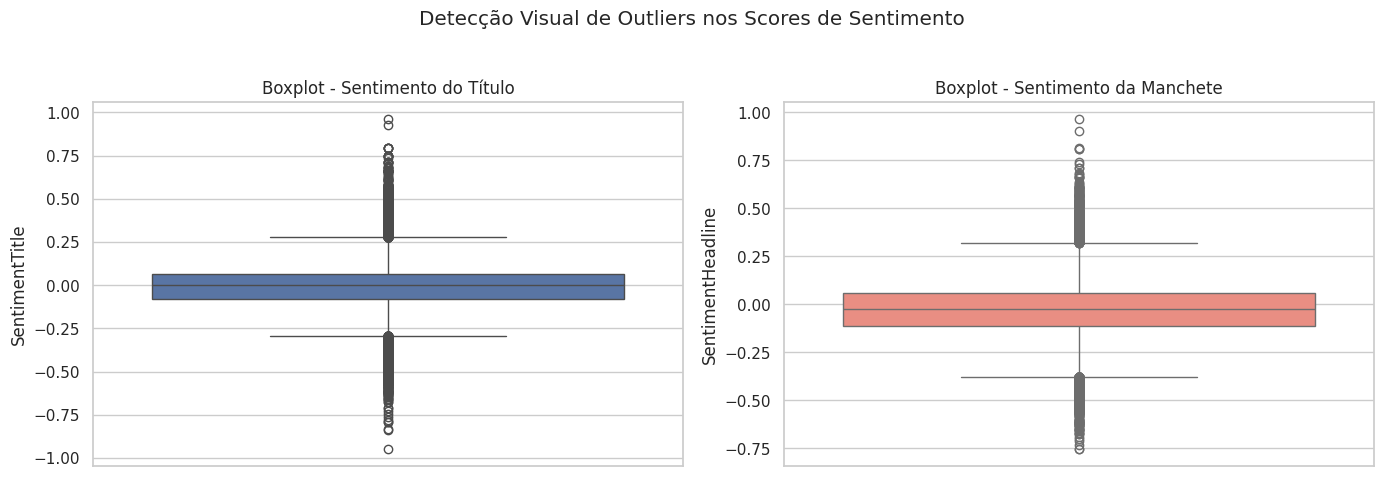

Boxplots acima ajudam a identificar outliers visuais nos sentimentos.

Verificando possíveis erros/variações em 'Topic':
Topic
economy      33928
microsoft    21858
obama        28610
palestine     8843
Name: count, dtype: int64

Datas potencialmente inválidas (antes de 1990): 0
Datas potencialmente inválidas (no futuro): 0

=== 3. LIMPEZA DOS DADOS (DATA CLEANING) ===

Tamanho do DataFrame ANTES da limpeza: (93239, 11)

3.1 Tratamento de Valores Nulos:
Valores ausentes ANTES do tratamento:
Headline         15
Source          279
Facebook      11602
GooglePlus     5744
LinkedIn       5745
dtype: int64

Valores ausentes DEPOIS do tratamento:
Headline         15
Facebook      11602
GooglePlus     5744
LinkedIn       5745
dtype: int64

3.2 Padronização:
Padronizando 'Topic' para minúsculas...
Valores únicos de 'Topic' após padronização (Top 10):
Topic
economy      33928
obama        28610
microsoft    21858
palestine     8843
Name: count, dtype: int64
Removendo espaços extras em 'Source'.

<ipython-input-2-cb9e851513e7>:324: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Topic'].replace('', MISSING_VALUE_PLACEHOLDER, inplace=True)
<ipython-input-2-cb9e851513e7>:325: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value


3.3 Correção de Inconsistências:
Nenhuma correção adicional aplicada neste exemplo (além de padronização).

3.4 Remoção de Duplicatas e Registros Irrelevantes:
Número de linhas ANTES da remoção de duplicatas: 93239
Número de linhas DEPOIS da remoção de duplicatas (baseado em ['IDLink']): 93235
Encontrados 1 registros com manchete < 10 caracteres (potencialmente irrelevantes).

Tamanho FINAL do DataFrame após limpeza: (93235, 11)

=== VERIFICAÇÃO FINAL DO DATAFRAME LIMPO ===

Primeiras 5 linhas do DataFrame limpo:
    IDLink                                              Title                                           Headline                                    Source    Topic         PublishDate  SentimentTitle  SentimentHeadline  Facebook  GooglePlus  LinkedIn
0  99248.0   Obama Lays Wreath at Arlington National Cemetery  Obama Lays Wreath at Arlington National Cemete...                                 USA TODAY    obama 2002-04-02 00:00:00        0.000000          -0.053300       NaN 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurações de Visualização ---
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None) # Mostrar todas as colunas
pd.set_option('display.width', 1000) # Largura do display para .head()

# --- Constantes ---
FILE_PATH = 'News_Final.csv'
DUPLICATE_SUBSET = ['IDLink'] # Coluna(s) para identificar duplicatas
MISSING_VALUE_PLACEHOLDER = 'Unknown'

# --- Funções Auxiliares ---
def print_separator(title=""):
    """Imprime um separador formatado."""
    print("\n" + "="*80)
    if title:
        print(f"=== {title.upper()} ===")
    print("="*80 + "\n")

def check_dataset_criteria(df):
    """Verifica se o dataset atende aos critérios mínimos."""
    print("Verificando critérios do dataset:")
    criteria_met = True
    # Mínimo de 10 colunas
    num_cols = df.shape[1]
    if num_cols >= 10:
        print(f"[OK] Número de colunas: {num_cols} (>= 10)")
    else:
        print(f"[FALHA] Número de colunas: {num_cols} (< 10)")
        criteria_met = False

    # Mínimo de 10 mil linhas
    num_rows = df.shape[0]
    if num_rows >= 10000:
        print(f"[OK] Número de linhas: {num_rows} (>= 10000)")
    else:
        print(f"[FALHA] Número de linhas: {num_rows} (< 10000)")
        criteria_met = False

    # Coluna Date ou Timestamp
    has_date_col = any(pd.api.types.is_datetime64_any_dtype(df[col]) for col in df.columns)
    # Tenta converter 'PublishDate' caso ainda não seja datetime
    if not has_date_col and 'PublishDate' in df.columns:
         try:
             pd.to_datetime(df['PublishDate'], errors='coerce')
             # Verifica novamente após tentativa de conversão
             has_date_col_after_conversion = any(pd.api.types.is_datetime64_any_dtype(pd.to_datetime(df[col], errors='coerce')) for col in df.columns if col == 'PublishDate')
             if has_date_col_after_conversion:
                 print(f"[OK] Contém coluna Date/Timestamp ('PublishDate' pode ser convertida)")
                 has_date_col = True # Marca como tendo coluna de data
             else:
                print(f"[FALHA] Nenhuma coluna Date/Timestamp encontrada ('PublishDate' não pôde ser convertida)")
                criteria_met = False
         except:
              print(f"[FALHA] Nenhuma coluna Date/Timestamp encontrada (Erro ao converter 'PublishDate')")
              criteria_met = False
    elif has_date_col:
         print(f"[OK] Contém coluna Date/Timestamp")
    else:
         print(f"[FALHA] Nenhuma coluna Date/Timestamp encontrada")
         criteria_met = False

    # Coluna String
    has_string_col = any(df[col].dtype == 'object' for col in df.columns)
    if has_string_col:
        string_cols = [col for col in df.columns if df[col].dtype == 'object']
        print(f"[OK] Contém coluna(s) String: {string_cols}")
    else:
        print(f"[FALHA] Nenhuma coluna String encontrada")
        criteria_met = False

    if criteria_met:
        print(">>> O Dataset atende a todos os critérios.")
    else:
        print(">>> O Dataset NÃO atende a todos os critérios.")
    return criteria_met

# --- 1. Exploração Inicial dos Dados ---
print_separator("1. Exploração Inicial dos Dados")

# 1.1 Carregamento do Dataset
print(f"1.1 Carregando dataset de: {FILE_PATH}")
try:
    # Tenta carregar com UTF-8, que é o mais comum
    df = pd.read_csv(FILE_PATH)
    print("Dataset carregado com sucesso (UTF-8).")
except UnicodeDecodeError:
    print("Falha ao carregar com UTF-8. Tentando com 'latin1'...")
    try:
        df = pd.read_csv(FILE_PATH, encoding='latin1')
        print("Dataset carregado com sucesso (latin1).")
    except Exception as e:
        print(f"Erro fatal ao carregar o CSV com 'latin1': {e}")
        exit()
except FileNotFoundError:
    print(f"Erro: Arquivo '{FILE_PATH}' não encontrado.")
    exit()
except Exception as e:
    print(f"Erro inesperado ao carregar o CSV: {e}")
    exit()

# 1.2 Descrição Geral
print("\n1.2 Descrição Geral do Dataset (Inicial)")
print(f"Número de Registros (Linhas): {df.shape[0]}")
print(f"Número de Colunas: {df.shape[1]}")
print("\nNomes das Colunas:")
print(df.columns.tolist())
print("\nTipos de Dados por Coluna:")
print(df.dtypes)
print("\nPrimeiras 5 Linhas:")
print(df.head())

# Verifica critérios antes de continuar
if not check_dataset_criteria(df):
    print("Encerrando o script pois o dataset não atende aos critérios.")
    exit()

# 1.3 Identificação Inicial de Dados Ausentes, Duplicados e Inconsistências
print("\n1.3 Identificação Inicial de Problemas")
print("\nValores Ausentes (NaN) por Coluna:")
# Considera strings vazias como ausentes também para esta contagem inicial
missing_counts = df.isnull().sum()
for col in df.select_dtypes(include='object').columns:
    empty_string_count = (df[col] == '').sum()
    if empty_string_count > 0:
        print(f"   - Coluna '{col}' tem {empty_string_count} strings vazias.")
        # Adiciona ao total de ausentes para uma visão completa
        missing_counts[col] = missing_counts.get(col, 0) + empty_string_count
print("Contagem Total de Ausentes (NaN + Strings Vazias):")
print(missing_counts[missing_counts > 0]) # Mostra apenas colunas com ausentes

print(f"\nValores Especiais (-1) em Colunas de Redes Sociais:")
social_cols = ['Facebook', 'GooglePlus', 'LinkedIn']
for col in social_cols:
    if col in df.columns:
        count_minus_one = (pd.to_numeric(df[col], errors='coerce') == -1).sum()
        if count_minus_one > 0:
            print(f"   - Coluna '{col}' tem {count_minus_one} valores iguais a -1.")
    else:
        print(f"   - Coluna '{col}' não encontrada no dataset.")


print(f"\nRegistros Duplicados (baseado em {DUPLICATE_SUBSET}):")
# Usa IDLink como identificador único primário
num_duplicates = df.duplicated(subset=DUPLICATE_SUBSET).sum()
print(f"Número de linhas duplicadas (considerando apenas '{DUPLICATE_SUBSET}'): {num_duplicates}")

# Checa duplicatas completas (menos provável, mas bom verificar)
num_full_duplicates = df.duplicated().sum()
print(f"Número de linhas completamente duplicadas: {num_full_duplicates}")

print("\nInconsistências Potenciais (Exemplos):")
print("Valores únicos na coluna 'Topic' (para verificar variações):")
print(df['Topic'].unique()[:20]) # Mostra os 20 primeiros valores únicos
print("\nValores únicos na coluna 'Source' (Top 10 - pode haver variações):")
print(df['Source'].value_counts().head(10))
print("\nVerificando range das colunas de Sentimento:")
print(f"  SentimentTitle - Min: {df['SentimentTitle'].min():.4f}, Max: {df['SentimentTitle'].max():.4f}")
print(f"  SentimentHeadline - Min: {df['SentimentHeadline'].min():.4f}, Max: {df['SentimentHeadline'].max():.4f}")
# Verifica se existem valores fora do range esperado [-1, 1]
invalid_sentiment_title = df[(df['SentimentTitle'] < -1) | (df['SentimentTitle'] > 1)].shape[0]
invalid_sentiment_headline = df[(df['SentimentHeadline'] < -1) | (df['SentimentHeadline'] > 1)].shape[0]
print(f"  Registros com SentimentTitle fora de [-1, 1]: {invalid_sentiment_title}")
print(f"  Registros com SentimentHeadline fora de [-1, 1]: {invalid_sentiment_headline}")


# --- 2. Geração de Perfil dos Dados (Data Profiling) ---
print_separator("2. Geração de Perfil dos Dados (Data Profiling)")

# Pré-processamento leve para profiling (conversão de data)
print("Convertendo 'PublishDate' para datetime para análise...")
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')
# Remove linhas onde a conversão falhou (se houver)
rows_before = len(df)
df.dropna(subset=['PublishDate'], inplace=True)
if len(df) < rows_before:
    print(f"{rows_before - len(df)} linhas removidas devido a datas inválidas.")

# Trata -1 antes de calcular estatísticas descritivas
print("Convertendo -1 para NaN nas colunas sociais para profiling...")
for col in social_cols:
     if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').replace(-1, np.nan)

# 2.1 Estatísticas Descritivas
print("\n2.1 Estatísticas Descritivas:")
# Para colunas numéricas
print("Descritivas Numéricas:")
print(df.describe(percentiles=[.01, .25, .5, .75, .99]))
# Para colunas categóricas/objeto
print("\nDescritivas Categóricas/Objeto:")
print(df.describe(include=['object', 'category'])) # Assumindo que não há 'category' ainda
# Calcula a moda para colunas numéricas onde pode ser útil
print("\nModa para Colunas Selecionadas:")
for col in ['SentimentTitle', 'SentimentHeadline', 'Topic']:
    try:
        mode_val = df[col].mode()
        print(f"  Moda de '{col}': {mode_val.tolist()}")
    except Exception as e:
        print(f"  Não foi possível calcular a moda para '{col}': {e}")


# 2.2 Distribuição das Variáveis
print("\n2.2 Distribuição das Variáveis (Visualizações):")

# Variáveis Numéricas (Sentimentos)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['SentimentTitle'].dropna(), kde=True, bins=30)
plt.title('Distribuição - Sentimento do Título')
plt.xlabel('Score Sentimento Título')

plt.subplot(1, 2, 2)
sns.histplot(df['SentimentHeadline'].dropna(), kde=True, bins=30, color='salmon')
plt.title('Distribuição - Sentimento da Manchete')
plt.xlabel('Score Sentimento Manchete')

plt.suptitle('Distribuição dos Scores de Sentimento')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Variáveis Categóricas (Topic e Source)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
topic_plot = sns.countplot(y=df['Topic'], order=df['Topic'].value_counts().index, palette='viridis')
plt.title('Distribuição de Tópicos')
plt.xlabel('Contagem')
plt.ylabel('Tópico')
# Adiciona contagens nas barras (opcional, pode ficar poluído)
# for container in topic_plot.containers:
#    topic_plot.bar_label(container, label_type='edge', fontsize=8)


plt.subplot(1, 2, 2)
top_sources = df['Source'].value_counts().nlargest(15)
source_plot = sns.countplot(y=df[df['Source'].isin(top_sources.index)]['Source'], order=top_sources.index, palette='magma')
plt.title('Distribuição das Top 15 Fontes')
plt.xlabel('Contagem')
plt.ylabel('Fonte')
# Adiciona contagens nas barras (opcional)
# for container in source_plot.containers:
#    source_plot.bar_label(container, label_type='edge', fontsize=8)

plt.suptitle('Distribuição de Variáveis Categóricas')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2.3 Colunas com Alta Cardinalidade ou Baixa Variabilidade
print("\n2.3 Análise de Cardinalidade e Variabilidade:")
print("Contagem de Valores Únicos por Coluna:")
cardinality = df.nunique().sort_values(ascending=False)
print(cardinality)

high_cardinality_cols = cardinality[cardinality > 0.5 * len(df)].index.tolist() # Ex: mais de 50% de valores únicos
low_cardinality_cols = cardinality[cardinality <= 5].index.tolist() # Ex: 5 ou menos valores únicos
print(f"\nColunas com potencial Alta Cardinalidade (Ex: >50% únicas): {high_cardinality_cols}")
print(f"Colunas com potencial Baixa Cardinalidade (Ex: <=5 únicas): {low_cardinality_cols}")

print("\nVariabilidade (Desvio Padrão para numéricas - ver describe() acima)")
print("Distribuição de Frequência para Tópicos (Exemplo de variabilidade categórica):")
print(df['Topic'].value_counts(normalize=True) * 100) # Percentual


# 2.4 Identificação de Outliers e Possíveis Erros
print("\n2.4 Identificação de Outliers e Erros Potenciais:")
# Outliers numéricos (visualização)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['SentimentTitle'].dropna())
plt.title('Boxplot - Sentimento do Título')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['SentimentHeadline'].dropna(), color='salmon')
plt.title('Boxplot - Sentimento da Manchete')

plt.suptitle('Detecção Visual de Outliers nos Scores de Sentimento')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Boxplots acima ajudam a identificar outliers visuais nos sentimentos.")

# Possíveis erros de digitação/formatação (exemplo com Topic)
print("\nVerificando possíveis erros/variações em 'Topic':")
print(df['Topic'].value_counts().sort_index()) # Ordena alfabeticamente para ver variações

# Verifica datas fora de um range razoável (ex: antes de 1990 ou depois de hoje)
current_date = pd.Timestamp.now()
unlikely_dates_past = df[df['PublishDate'] < '1990-01-01'].shape[0]
unlikely_dates_future = df[df['PublishDate'] > current_date].shape[0]
print(f"\nDatas potencialmente inválidas (antes de 1990): {unlikely_dates_past}")
print(f"Datas potencialmente inválidas (no futuro): {unlikely_dates_future}")


# --- 3. Limpeza dos Dados (Data Cleaning) ---
print_separator("3. Limpeza dos Dados (Data Cleaning)")
df_cleaned = df.copy() # Cria uma cópia para limpeza
print(f"Tamanho do DataFrame ANTES da limpeza: {df_cleaned.shape}")

# 3.1 Tratamento de Valores Nulos
print("\n3.1 Tratamento de Valores Nulos:")
print("Valores ausentes ANTES do tratamento:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# Estratégia:
# - 'Topic', 'Source': Preencher com MISSING_VALUE_PLACEHOLDER ('Unknown')
# - Social ('Facebook', 'GooglePlus', 'LinkedIn'): Já tratados (-1 -> NaN). Decisão: Manter NaN ou preencher com 0?
#      Para análise de correlação, NaN é melhor. Para outras análises (ex: média de likes), 0 pode ser melhor.
#      Vamos manter NaN por enquanto. Se fosse preencher: df_cleaned[social_cols] = df_cleaned[social_cols].fillna(0)
# - SentimentTitle, SentimentHeadline: Se houver NaNs, investigar. Poderia remover linhas ou imputar (média/mediana).
#      Vamos verificar e remover se forem poucos.
initial_rows = len(df_cleaned)
df_cleaned.dropna(subset=['SentimentTitle', 'SentimentHeadline'], inplace=True)
rows_removed_sentiment = initial_rows - len(df_cleaned)
if rows_removed_sentiment > 0:
    print(f"  - Removidas {rows_removed_sentiment} linhas com sentimento ausente.")

df_cleaned['Topic'] = df_cleaned['Topic'].fillna(MISSING_VALUE_PLACEHOLDER)
df_cleaned['Source'] = df_cleaned['Source'].fillna(MISSING_VALUE_PLACEHOLDER)
# Trata também strings vazias que não foram pegas antes
df_cleaned['Topic'].replace('', MISSING_VALUE_PLACEHOLDER, inplace=True)
df_cleaned['Source'].replace('', MISSING_VALUE_PLACEHOLDER, inplace=True)


print("\nValores ausentes DEPOIS do tratamento:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0]) # Deve mostrar apenas colunas sociais

# 3.2 Padronização de Categorias e Formatos
print("\n3.2 Padronização:")
# Padronizar 'Topic' para minúsculas
print("Padronizando 'Topic' para minúsculas...")
df_cleaned['Topic'] = df_cleaned['Topic'].str.lower()
print("Valores únicos de 'Topic' após padronização (Top 10):")
print(df_cleaned['Topic'].value_counts().head(10))

# Padronizar 'Source' - Mais complexo, pode ter variações sutis.
# Exemplo simples: remover espaços extras no início/fim
print("Removendo espaços extras em 'Source'...")
df_cleaned['Source'] = df_cleaned['Source'].str.strip()
# Poderia fazer mais (ex: .str.lower()), mas pode agrupar fontes diferentes.

# Formato de Data já tratado na conversão para datetime.
# Formato Numérico já tratado na conversão/limpeza.

# 3.3 Correções em Dados Inconsistentes
print("\n3.3 Correção de Inconsistências:")
# Exemplo: Se houvesse sentimentos fora de [-1, 1] poderíamos usar clip
# df_cleaned['SentimentTitle'] = df_cleaned['SentimentTitle'].clip(-1, 1)
# df_cleaned['SentimentHeadline'] = df_cleaned['SentimentHeadline'].clip(-1, 1)
# Mas já verificamos que não há, então pulamos.

# Outras inconsistências poderiam ser corrigidas aqui com base no profiling
# Ex: Se 'obama' e 'obama ' existissem, o .str.strip() ajudaria.
# Se 'Microsof' existisse, usaríamos .replace({'Microsof': 'microsoft'})
print("Nenhuma correção adicional aplicada neste exemplo (além de padronização).")

# 3.4 Remoção de Duplicatas e Registros Irrelevantes
print("\n3.4 Remoção de Duplicatas e Registros Irrelevantes:")
print(f"Número de linhas ANTES da remoção de duplicatas: {len(df_cleaned)}")
# Remove duplicatas com base na(s) coluna(s) chave
df_cleaned.drop_duplicates(subset=DUPLICATE_SUBSET, keep='first', inplace=True)
print(f"Número de linhas DEPOIS da remoção de duplicatas (baseado em {DUPLICATE_SUBSET}): {len(df_cleaned)}")

# Remoção de registros irrelevantes (Exemplo: Título ou Manchete muito curtos)
min_headline_length = 10 # Exemplo de critério
irrelevant_short_headline = df_cleaned[df_cleaned['Headline'].str.len() < min_headline_length].shape[0]
if irrelevant_short_headline > 0:
    print(f"Encontrados {irrelevant_short_headline} registros com manchete < {min_headline_length} caracteres (potencialmente irrelevantes).")
    # Opção de remover:
    # initial_rows = len(df_cleaned)
    # df_cleaned = df_cleaned[df_cleaned['Headline'].str.len() >= min_headline_length]
    # print(f"Removidas {initial_rows - len(df_cleaned)} linhas com manchetes curtas.")
else:
    print(f"Nenhum registro encontrado com manchete < {min_headline_length} caracteres.")

print(f"\nTamanho FINAL do DataFrame após limpeza: {df_cleaned.shape}")

# --- Verificação Final ---
print_separator("Verificação Final do DataFrame Limpo")
print("Primeiras 5 linhas do DataFrame limpo:")
print(df_cleaned.head())
print("\nInformações gerais do DataFrame limpo:")
df_cleaned.info()
print("\nValores ausentes restantes:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

print_separator("Script Concluído")

# Opcional: Salvar o dataframe limpo
# try:
#     df_cleaned.to_csv('News_Final_Limpado.csv', index=False, encoding='utf-8')
#     print("\nDataFrame limpo salvo em 'News_Final_Limpado.csv'")
# except Exception as e:
#     print(f"\nErro ao salvar o DataFrame limpo: {e}")